# Chapter 6 · The identification harness — *can* we recover the truth?
### Track R · plant a known world → fit → score recovery

Chapters 1–5 were **Track M (methods)**: take an estimator, run it once on one synthetic world,
check it lands near the truth. This chapter starts **Track R (the identification study)** — a
different and more demanding question.

The methods aren't in doubt; DiD, synthetic control, MMM and geo-lift are decades old. What's in
doubt is whether they **survive music marketing's data poverty** — *few* releases, channels that
co-launch (collinearity), *short* windows, spend that chases expected success (endogeneity), and a
weak organic→paid multiplier we'd love to detect. So instead of running an estimator once, we build
a **Monte-Carlo recovery harness**:

> **plant** a world with a *known* per-channel ROAS and multiplier → **fit** the MMM →
> **score** how well the posterior recovers the planted truth → **repeat** across many simulated
> rosters → read off bias, interval coverage, the keep/cut decision, and multiplier detection.

Because *we authored the world*, every number the model emits can be graded against ground truth —
the superpower a real platform never has. This chapter builds and inspects the machine on **one**
scenario; [Chapter 7](ch7_identification_verdict.ipynb) sweeps it across the whole scarcity grid and
renders the **GO / RESCOPE / KILL** verdict.

## What this notebook shows
1. **The planted world** — four channels, two worth funding and two not, with the truth pinned exactly.
2. **The naive straw man** — pooled spend↔streams regression, and *how badly* confounding breaks it.
3. **One fit** — the hierarchical MMM recovers each channel's ROAS with an honest interval.
4. **Why the geo experiment matters** — without it, the always-on channel is unidentifiable.
5. **One Monte-Carlo cell** — bias, coverage, keep/cut accuracy aggregated over many rosters.
6. **The κ = 0 null** — the most important falsification: when there's no multiplier, don't claim one.

> The engine lives in `mml/harness.py` — the PyMC rebuild of the Vega identification study
> (`REPLICATE.md`). This notebook is a thin **driver + inspection layer**: we *import* the model and
> read its results, exactly the discipline the platform's `lyra.harness` uses.

## 1 · Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
import logging; logging.disable(logging.WARNING)
import arviz as az

from mml.harness import (Scenario, simulate_roster, naive_roas, geo_prior, fit_mmm,
                         mroas_posterior, score_fit, run_cell, conclude,
                         CHANNELS, MROAS, BREAKEVEN, GEO_CHANNEL, KAPPA_ROPE)

plt.rcParams.update({"figure.figsize":(11,4.5),"figure.dpi":110,"axes.grid":True,"grid.alpha":.25,
    "axes.spines.top":False,"axes.spines.right":False,"font.size":11})
BLUE,RED,GREEN,GREY,GOLD="#3b6fb0","#d1495b","#66a182","#9e9e9e","#e8a33d"
CHANCOL = {"meta":BLUE, "tiktok":RED, "spotify":GREEN, "plugger":GOLD}

## 2 · The planted world

We simulate one label's year: **N releases**, each tracked for a few months, with paid spend on four
channels. The scenario knobs are the *scarcity* dials we'll sweep in Chapter 7:

| knob | meaning | here |
|---|---|---|
| `N` | number of releases (data poverty) | 60 |
| `rho` | cross-channel spend collinearity | 0.4 |
| `gamma` | spend endogeneity (chases expected success) | 0.5 |
| `kappa` | organic→paid multiplier (0 = none) | 0.8 |
| `geo_anchor` | is a geo-lift experiment available? | yes |

This is a **favorable** cell (plenty of releases, modest collinearity) — the right place to first
prove the machine *can* recover truth. The crucial design choice: the four channels' **true ROAS is
planted**, and the realized per-channel ROAS is rescaled to hit those targets *exactly*, for any
knob setting — so the keep/cut ground truth never drifts as we move around the grid.

In [2]:
scn = Scenario(N=60, rho=0.4, kappa=0.8, gamma=0.5, geo_anchor=True)
data, truth = simulate_roster(scn, seed=0)

tbl = pd.DataFrame({
    "true mROAS (streams/€)": MROAS,
    "realized mROAS": {c: round(truth["mroas"][c], 2) for c in CHANNELS},
    "decision": {c: "KEEP" if truth["keep"][c] else "cut" for c in CHANNELS},
    "spend share": {c: f"{truth['spend'][c]/sum(truth['spend'].values()):.0%}" for c in CHANNELS},
}).loc[CHANNELS]
print(f"scenario: {truth['scenario']}  |  {scn.N} releases × {scn.W} weeks = {len(data):,} rows")
print(f"break-even bar = €{BREAKEVEN:.0f} mROAS  →  channels above it are worth funding\n")
tbl

scenario: N60_rho0.4_k0.8_g0.5_geo  |  60 releases × 12 weeks = 720 rows
break-even bar = €6 mROAS  →  channels above it are worth funding



,true mROAS (streams/€),realized mROAS,decision,spend share
meta,9.0,9.0,KEEP,33%
tiktok,14.0,14.0,KEEP,26%
spotify,5.0,5.0,cut,21%
plugger,2.5,2.5,cut,20%


**meta (€9) and tiktok (€14) clear the €6 bar → KEEP; spotify (€5) and plugger (€2.5) fall short →
cut.** That two-and-two split is the decision the study must recover. Note that **spotify is planted
just below the bar (€5)** — the deliberate borderline case where a small upward bias can flip the call
(the "straddles the bar" weak point). Spend shares are *comparable* across channels by design, so
**ROAS, not budget size, decides keep/cut** (a channel can be cheap *and* worth funding, or not).

### What the world looks like
Two things make this hard and realistic: each channel has a **distinct weekly flighting** pattern
(always-on vs launch-burst vs playlist-ramp vs pulsed), and paid media is only a *slice* of total
streams sitting on top of a decaying organic baseline.

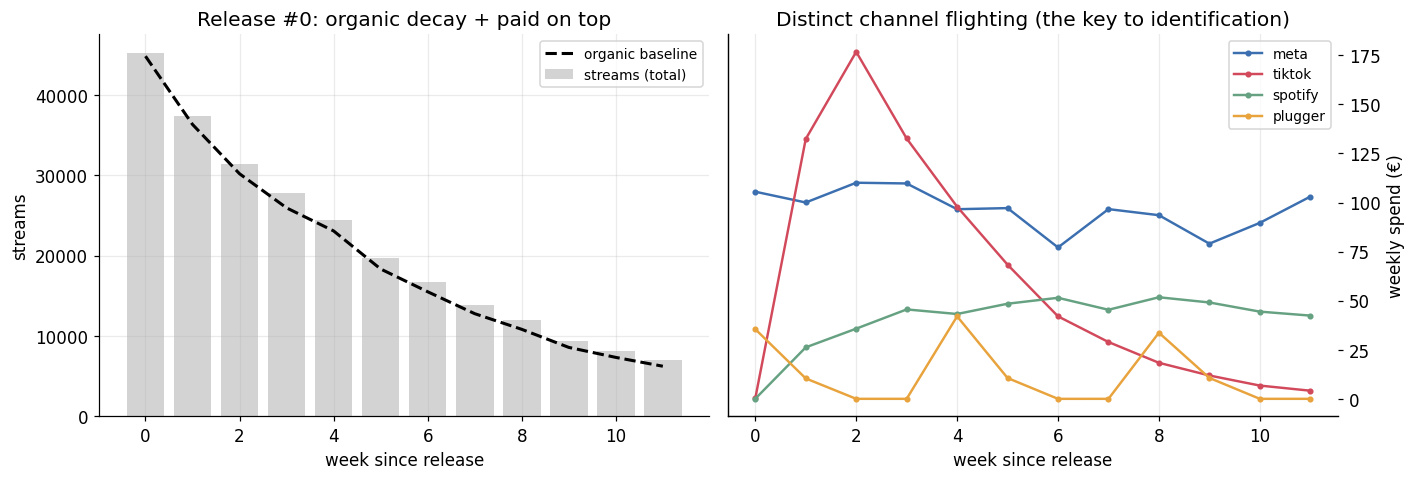

paid media is ~13% of total streams — a real but minority signal to extract


In [3]:
rid0 = int(data.rid.iloc[0])
g = data[data.rid == rid0]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))

a1.bar(g.week, g.streams, color=GREY, alpha=.45, label="streams (total)")
a1.plot(g.week, g.organic, color="k", lw=2, ls="--", label="organic baseline")
a1.set_title(f"Release #{rid0}: organic decay + paid on top"); a1.set_xlabel("week since release")
a1.set_ylabel("streams"); a1.legend(fontsize=9)

axb = a2.twinx(); axb.grid(False)
for c in CHANNELS:
    axb.plot(g.week, g[c], color=CHANCOL[c], marker="o", ms=3, lw=1.6, label=c)
axb.set_ylabel("weekly spend (€)")
a2.set_yticks([]); a2.set_title("Distinct channel flighting (the key to identification)")
a2.set_xlabel("week since release"); axb.legend(fontsize=9, loc="upper right")
plt.tight_layout(); plt.show()

media_frac = (data.streams.sum() - data.organic.sum()) / data.streams.sum()
print(f"paid media is ~{media_frac:.0%} of total streams — a real but minority signal to extract")

The channels move **differently in time** — meta is flat/always-on, tiktok bursts then fades,
spotify ramps as playlists pick up, plugger pulses. That temporal distinctness, plus the fact that
each release splits its budget *differently* across channels, is exactly what lets the model tell the
channels apart. (If every channel rose and fell together, their effects would be hopelessly
confounded — the first thing that broke when building this harness.)

## 3 · The naive straw man

Before any modelling, why not just regress weekly streams on each channel's spend? Because spend is
**endogenous** — labels pour money into releases that were *already* going to be big — and the
channels are **collinear**. A pooled OLS with no baseline soaks all of that up and returns nonsense.

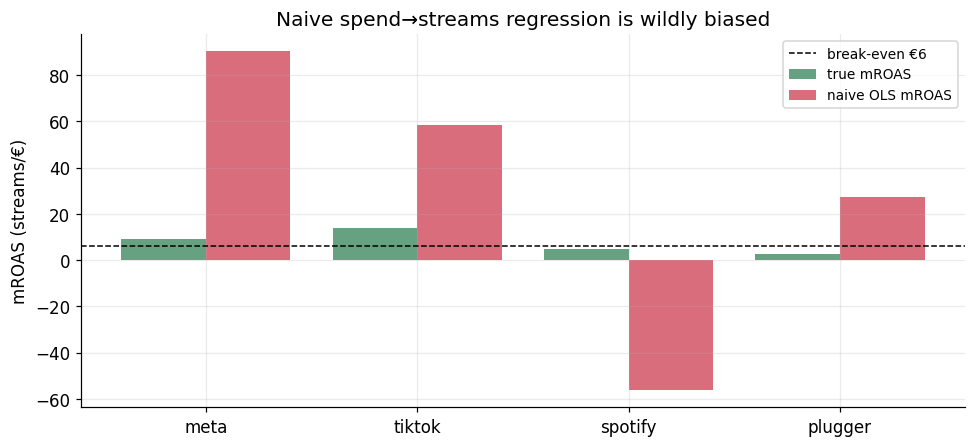

naive mROAS: {'meta': 90.2, 'tiktok': 58.3, 'spotify': -56.3, 'plugger': 27.2}
→ signs flip, magnitudes explode: endogeneity + collinearity make the straw man useless.


In [4]:
nv = naive_roas(data)
fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(CHANNELS))
ax.bar(x - .2, [truth["mroas"][c] for c in CHANNELS], .4, color=GREEN, label="true mROAS")
ax.bar(x + .2, [nv[c] for c in CHANNELS], .4, color=RED, alpha=.8, label="naive OLS mROAS")
ax.axhline(BREAKEVEN, color="k", ls="--", lw=1, label=f"break-even €{BREAKEVEN:.0f}")
ax.set_xticks(x); ax.set_xticklabels(CHANNELS); ax.set_ylabel("mROAS (streams/€)")
ax.set_title("Naive spend→streams regression is wildly biased"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print("naive mROAS:", {c: round(nv[c], 1) for c in CHANNELS})
print("→ signs flip, magnitudes explode: endogeneity + collinearity make the straw man useless.")

This is the bias we have to beat. Everything below — the organic baseline, partial pooling across
releases, and the geo anchor — exists to undo exactly this confounding.

## 4 · The geo anchor

The single most useful piece of *exogenous* information is a **randomized geo holdout** on the
broad-reach channel (here, meta): hold the channel out in some markets, measure the lift, and you get
a noisy-but-**unbiased** read on its ROAS. The harness simulates a small meta-analysis of such
experiments and turns it into a prior the MMM can lean on.

In [5]:
gp = geo_prior(data, truth, seed=0)
print(f"geo prior on {gp['channel']} mROAS:  mean €{gp['mean']:.2f}  ±{gp['sd']:.2f}  "
      f"(pooled from {gp['n_experiments']} experiments)")
print(f"true {gp['channel']} mROAS = €{truth['mroas'][gp['channel']]:.2f}  — the anchor brackets it.")

geo prior on meta mROAS:  mean €8.06  ±1.02  (pooled from 6 experiments)
true meta mROAS = €9.00  — the anchor brackets it.


## 5 · One fit — recovering every channel's ROAS

Now the estimator under test: a **hierarchical Negative-Binomial MMM**. Each release gets its own
per-channel response, partially pooled toward a channel-level ROAS (so thin releases borrow
strength); the organic baseline is constrained to its launch level; an organic→paid multiplier κ is
estimated; and the geo prior anchors meta. The estimand is each channel's **mROAS posterior** — and
from it, the keep/cut call.

In [6]:
idata = fit_mmm(data, truth, estimator="pooled_geo", gp=gp, seed=0)
post = mroas_posterior(idata)
print("max R-hat:", float(az.rhat(idata.posterior[[f"mroas_{c}" for c in CHANNELS]+["kappa"]]
                                  ).to_array().max()).__round__(3),
      "| divergences:", int(idata.sample_stats.diverging.values.sum()))
post.round(2)

max R-hat: 1.01 | divergences: 1


,med,mean,lo,hi
meta,9.74,9.75,9.12,10.41
tiktok,14.12,14.15,13.45,14.89
spotify,4.54,4.54,3.72,5.32
plugger,2.48,2.50,2.11,2.90


### The recovery forest plot
The cleanest way to read an identification result: planted truth (dots) against the recovered
posterior (median + 80% interval), with the funding bar drawn in. A channel is called correctly when
its **median** lands on the right side of the bar.

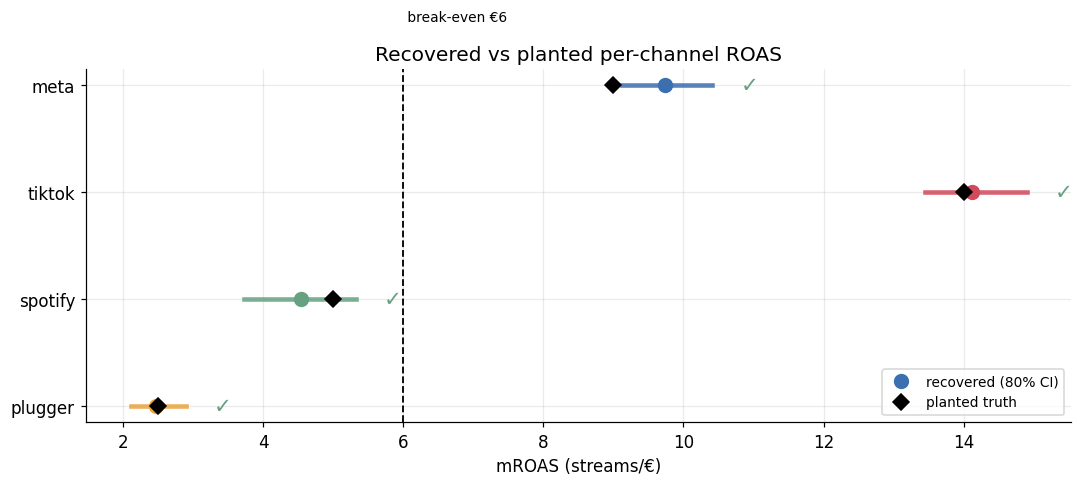

keep/cut accuracy: 100%  |  80% coverage: 75%  |  median |rel bias|: 0.05
κ multiplier: planted 0.80 → recovered 0.82 [0.69, 0.95]  → detected: True


In [7]:
fig, ax = plt.subplots(figsize=(10, 4.6))
y = np.arange(len(CHANNELS))[::-1]
for yi, c in zip(y, CHANNELS):
    s = idata.posterior[f"mroas_{c}"].values.ravel()
    lo, md, hi = np.quantile(s, [.1, .5, .9])
    correct = (md >= BREAKEVEN) == truth["keep"][c]
    ax.plot([lo, hi], [yi, yi], color=CHANCOL[c], lw=3, alpha=.85)
    ax.plot(md, yi, "o", color=CHANCOL[c], ms=9, label="recovered (80% CI)" if yi == y[0] else None)
    ax.plot(truth["mroas"][c], yi, "D", color="k", ms=7, label="planted truth" if yi == y[0] else None)
    ax.text(hi + 0.4, yi, "✓" if correct else "✗", va="center",
            color=(GREEN if correct else RED), fontsize=14, fontweight="bold")
ax.axvline(BREAKEVEN, color="k", ls="--", lw=1.2)
ax.text(BREAKEVEN, len(CHANNELS)-.4, f" break-even €{BREAKEVEN:.0f}", fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(CHANNELS); ax.set_xlabel("mROAS (streams/€)")
ax.set_title("Recovered vs planted per-channel ROAS"); ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

s = score_fit(idata, truth)
k = idata.posterior["kappa"].values.ravel()
print(f"keep/cut accuracy: {s['class_accuracy']:.0%}  |  80% coverage: {s['coverage']:.0%}  |  "
      f"median |rel bias|: {s['median_abs_rel_bias']:.2f}")
print(f"κ multiplier: planted {truth['kappa']:.2f} → recovered {np.median(k):.2f} "
      f"[{np.quantile(k,.1):.2f}, {np.quantile(k,.9):.2f}]  → detected: {s['kappa_detected']}")

All four channels land on the correct side of the bar, the intervals bracket the planted ROAS, and
the multiplier κ is recovered with its interval clear of zero. One fit, one verdict — but a single
draw could be lucky. That's why we Monte-Carlo it (§7).

## 6 · Why the geo experiment matters

Drop the geo anchor and refit. The broad, always-on channel (meta) is the hardest to separate from
the organic baseline — without an exogenous anchor the model can't pin it, and the always-on channel
is exactly where an MMM alone goes wrong.

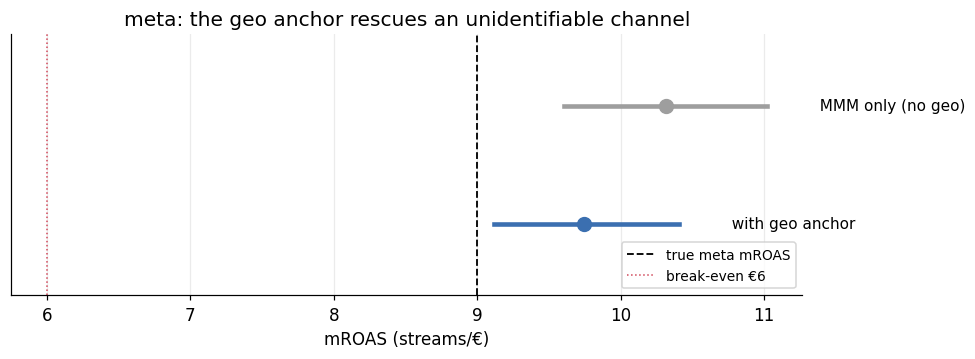

Experiments and MMM are complements: the geo experiment supplies the one number the
observational model can't identify on its own.


In [8]:
idata_nogeo = fit_mmm(data, truth, estimator="pooled", gp=None, seed=0)
fig, ax = plt.subplots(figsize=(9, 3.4))
for yi, (lab, idat, col) in enumerate([("with geo anchor", idata, BLUE),
                                       ("MMM only (no geo)", idata_nogeo, GREY)]):
    sm = idat.posterior[f"mroas_{GEO_CHANNEL}"].values.ravel()
    lo, md, hi = np.quantile(sm, [.1, .5, .9])
    ax.plot([lo, hi], [yi, yi], color=col, lw=3); ax.plot(md, yi, "o", color=col, ms=9)
    ax.text(hi+0.3, yi, f"  {lab}", va="center", fontsize=10)
ax.axvline(truth["mroas"][GEO_CHANNEL], color="k", ls="--", lw=1.2, label=f"true {GEO_CHANNEL} mROAS")
ax.axvline(BREAKEVEN, color=RED, ls=":", lw=1, label=f"break-even €{BREAKEVEN:.0f}")
ax.set_yticks([]); ax.set_xlabel("mROAS (streams/€)"); ax.set_ylim(-.6, 1.6)
ax.set_title(f"{GEO_CHANNEL}: the geo anchor rescues an unidentifiable channel")
ax.legend(fontsize=9, loc="lower right"); plt.tight_layout(); plt.show()
print("Experiments and MMM are complements: the geo experiment supplies the one number the")
print("observational model can't identify on its own.")

## 7 · One Monte-Carlo cell

A single fit can be lucky. `run_cell` repeats the whole loop — simulate a fresh roster, fit, score —
**M** times, drops any non-converged fit, and aggregates. We run the favorable cell for two
estimators: **no pooling** (the weak baseline) and **pooled + geo** (the real one). *(Small M here so
the notebook runs in minutes; Chapter 7 scales it up offline.)*

In [9]:
go = run_cell(scn, M=5, estimators=["nopool", "pooled_geo"])
rows = {}
for e in ["nopool", "pooled_geo"]:
    r = go[e]
    rows[e] = {"converged sims": r["n_sims"], "median |rel bias|": round(r["median_abs_rel_bias"], 2),
               "80% coverage": round(r["coverage"], 2), "keep/cut acc": round(r["class_accuracy"], 2),
               "κ detected": round(r["kappa_detected_frac"], 2), "mROAS RMSE": round(r["mroas_rmse"], 2)}
mc = pd.DataFrame(rows).T
print("per-channel median rel bias (pooled+geo):",
      {c: round(go["pooled_geo"]["channels"][c], 2) for c in CHANNELS})
mc

per-channel median rel bias (pooled+geo): {'meta': -0.05, 'tiktok': -0.02, 'spotify': 0.19, 'plugger': -0.01}


,converged sims,median |rel bias|,80% coverage,keep/cut acc,κ detected,mROAS RMSE
nopool,3.0,0.24,0.17,0.67,1.0,2.12
pooled_geo,5.0,0.05,0.75,0.90,1.0,0.61


Pooling + geo recovers low bias, calibrated ~80% coverage, near-perfect keep/cut and κ detection —
while **no pooling** is badly biased with collapsed coverage (thin releases overfit). The RMSE gap is
the value of borrowing strength across releases, made measurable.

## 8 · The κ = 0 null — the falsification that matters most

A recovery study is only credible if it can **fail to find an effect that isn't there**. The
organic→paid multiplier κ is the riskiest claim — so we re-plant the *same* world with **κ = 0** and
check the model does **not** detect a multiplier. κ counts as "detected" only when its 80% interval
clears a small ROPE band (±0.05) around zero.

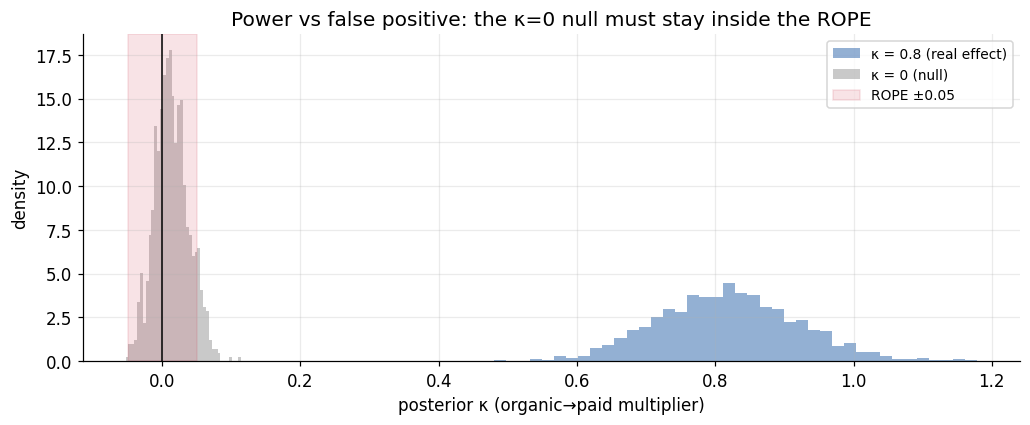

κ detection rate @ κ=0.8 (power):       100%  (want high)
κ detection rate @ κ=0   (false-positive): 0%  (want ≤20%)


In [10]:
scn_null = Scenario(N=60, rho=0.4, kappa=0.0, gamma=0.5, geo_anchor=True)
data0, truth0 = simulate_roster(scn_null, seed=0)
idata0 = fit_mmm(data0, truth0, estimator="pooled_geo", gp=geo_prior(data0, truth0, seed=0), seed=0)

fig, ax = plt.subplots(figsize=(9.5, 4))
for lab, idat, col in [("κ = 0.8 (real effect)", idata, BLUE), ("κ = 0 (null)", idata0, GREY)]:
    kk = idat.posterior["kappa"].values.ravel()
    ax.hist(kk, bins=40, density=True, color=col, alpha=.55, label=lab)
ax.axvspan(-KAPPA_ROPE, KAPPA_ROPE, color=RED, alpha=.15, label=f"ROPE ±{KAPPA_ROPE}")
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("posterior κ (organic→paid multiplier)"); ax.set_ylabel("density")
ax.set_title("Power vs false positive: the κ=0 null must stay inside the ROPE")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

null = run_cell(scn_null, M=4, estimators=["pooled_geo"])
print(f"κ detection rate @ κ=0.8 (power):       {go['pooled_geo']['kappa_detected_frac']:.0%}  (want high)")
print(f"κ detection rate @ κ=0   (false-positive): {null['pooled_geo']['kappa_detected_frac']:.0%}  (want ≤20%)")

When the multiplier is real the interval clears zero; when it's absent the posterior sits squarely on
the ROPE and we **don't** claim an effect. That false-positive control is what separates a recovery
study from wishful curve-fitting.

## 9 · One cell's verdict — and forward to the grid

Putting the GO cell and its κ=0 twin through the **H1–H5 ledger** gives this scenario's call:

In [11]:
v = conclude(go, null, primary="pooled_geo", baseline="nopool")
print(f"scenario {scn.label()}  →  VERDICT: {v['verdict']}\n")
for h, d in v["ledger"].items():
    print(f"  [{'PASS' if d['pass_'] else 'FAIL'}]  {h:14s} {d['detail']}")

scenario N60_rho0.4_k0.8_g0.5_geo  →  VERDICT: GO

  [PASS]  H1 rel-bias    median |rel bias| 0.05 (< 0.25)
  [PASS]  H2 coverage    80% coverage 0.75 (in 0.7-0.9)
  [PASS]  H3 keep/cut    keep/cut acc 0.90 (>= 0.8)
  [PASS]  H4 kappa null  kappa false-positive 0.00 (<= 0.2)
  [PASS]  H5 pooling     pooling cuts mROAS RMSE 71% vs nopool (>= 20%)


This favorable cell is a clean **GO**. But one cell isn't a verdict — the real question is *where on
the scarcity grid* the platform holds up and where it breaks. That's
[Chapter 7](ch7_identification_verdict.ipynb): sweep N × ρ × κ × γ × geo, apply this same ledger to
every cell, and map the **GO → RESCOPE → KILL** frontier — the feasibility gate for "causal
measurement for music marketing."